# Stage 6 — Hyperparameter Tuning
**Project:** LendingClub Loan Default Prediction  
**Methodology:** CRISP-DM  
**Notebook:** `06_tuning.ipynb`

---

## Purpose
Stage 5 established a solid **Recall baseline (0.8748)** but revealed weak
rank-ordering: ROC-AUC = 0.7099 and PR-AUC = 0.3317, both well below targets.
The diagnosis: the model's probability estimates are not well-separated. Class
weighting and threshold optimisation cannot fix that — only better hyperparameters
can improve discriminative power.

This stage uses **Optuna Bayesian search (TPE sampler)** to find the XGBoost
configuration that maximises PR-AUC — the metric most sensitive to improvement
on the minority class.

| Step | Configuration | Purpose |
|---|---|---|
| 1 | Optuna search (50 trials) over 9 parameters | Find best hyperparameters |
| 2 | Retrain best config on full training set | Stable final model |
| 3 | Re-optimise threshold on PR curve (F2) | Best operating point |
| 4 | Compare tuned vs Stage 5 baseline | Quantify tuning gain |

---

## Why Optuna (Bayesian Search)?
Grid search is combinatorially explosive with 9 parameters. Random search is
better but wastes budget on bad regions of the space. Optuna's **TPE sampler**
(Tree-structured Parzen Estimator) builds a probabilistic model of which
parameter regions produce good results, and samples the next trial from the
most promising areas. In practice, this finds good configurations in 30–50
trials that random search would need 200+ to match.

---

## Artifacts Produced
| File | Contents |
|---|---|
| `models/06_tuned_xgb.joblib` | Best tuned XGBoost model |
| `models/06_threshold.json` | Re-optimised threshold for tuned model |
| `models/06_tuning_results.json` | Full metrics comparison table |
| `models/06_optuna_study.pkl` | Optuna study object (full trial history) |
| `models/06_pr_roc_curves.png` | PR and ROC curves — tuned vs baseline |
| `models/06_confusion_matrix.png` | Confusion matrix at optimal threshold |
| `models/06_feature_importance.png` | Tuned model feature importance (top 20) |
| `models/06_optuna_history.png` | Optuna trial history and param importances |

---
## Concept: Why ROC-AUC ≠ PR-AUC and Which to Optimise Here

**ROC-AUC** measures the model's ability to rank a random default above a random
non-default. It treats both classes symmetrically — so with a 17% default rate,
the 83% non-defaults dominate the metric. A model can score ROC-AUC = 0.71 while
completely failing on the minority class because the majority class pairs carry
most of the weight.

**PR-AUC** (Precision-Recall AUC) only considers the positive (default) class.
Every point on the PR curve represents a threshold where the model must decide
how many defaults it catches (Recall) versus how many of its flags are real
(Precision). A model that randomly flags loans at the base rate scores
PR-AUC ≈ 0.17 — our 0.33 baseline beats random but has large headroom.

**We optimise PR-AUC in Optuna** because it is directly sensitive to how well the
model ranks actual defaults above non-defaults among its high-confidence
predictions — which is exactly where Stage 5 is weakest.

---
## 0. Imports & Config

We add `optuna` and `pickle` to the Stage 5 import stack. Optuna verbosity is
suppressed to `WARNING` — trial-level progress is tracked via a custom callback
instead, which is cleaner in a notebook environment.

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('data')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

INPUT_PATH = DATA_DIR / '04_engineered.parquet'

# ── Constants ──────────────────────────────────────────────────────────────────
RANDOM_SEED      = 42
SCALE_POS_WEIGHT = 4.8   # fixed — canonical imbalance ratio from Stage 2
FBETA_BETA       = 2     # weight Recall 2x in threshold optimisation
N_TRIALS         = 50    # Optuna budget — good balance of coverage vs runtime
OPTUNA_VAL_SIZE  = 0.20  # 20% of train set used as Optuna validation split

# ── Plot style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

print('Libraries loaded.')
print(f'XGBoost version : {xgb.__version__}')
print(f'Optuna version  : {optuna.__version__}')
print(f'Input           : {INPUT_PATH}')
print(f'Optuna trials   : {N_TRIALS}')
print(f'Val split size  : {OPTUNA_VAL_SIZE}')

Libraries loaded.
XGBoost version : 3.1.2
Optuna version  : 4.8.0
Input           : data/04_engineered.parquet
Optuna trials   : 50
Val split size  : 0.2


### Interpretation
All libraries loaded. Key constants to note:
- `SCALE_POS_WEIGHT = 4.8` is kept fixed throughout — it is not a hyperparameter
  to tune; it is derived from the data's imbalance ratio and should not change.
- `N_TRIALS = 50` is a practical choice for M1 hardware. Each trial trains an
  XGBoost model on ~845K rows (80% of train) with early stopping — expect
  roughly 15–40 minutes total depending on tree depth and n_estimators explored.
- `OPTUNA_VAL_SIZE = 0.20` means Optuna never sees the held-out test set.
  The search optimises on an internal validation split; final evaluation uses
  the untouched test set from Stage 2.

---
## 1. Load Data & Reconstruct Train/Test Split

Same load pattern as Stage 5. The `split` column carries the exact train/test
assignment from Stage 2. We also fill the 118 known residual nulls in the two
ratio features — medians are recomputed from train to avoid any test leakage.

In [2]:
# ── Load full engineered parquet ───────────────────────────────────────────────
df = pd.read_parquet(INPUT_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loaded: 1,321,847 rows × 72 columns
Memory: 363.2 MB


### Interpretation
Parquet loaded cleanly. Shape and memory should match Stage 5 exactly:
1,321,847 rows × 72 columns at ~363 MB. Any deviation here indicates a
re-run of Stage 4 changed something — check before proceeding.

In [3]:
# ── Reconstruct train/test from embedded split column ─────────────────────────
FEATURE_COLS = [c for c in df.columns if c not in ('target', 'split', 'id')]

train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

X_train = train_df[FEATURE_COLS].reset_index(drop=True)
y_train = train_df['target'].astype(int).reset_index(drop=True)

X_test  = test_df[FEATURE_COLS].reset_index(drop=True)
y_test  = test_df['target'].astype(int).reset_index(drop=True)

del df, train_df, test_df  # free ~363 MB — keep only the four arrays

# ── Fill 118 residual nulls in ratio features (fit on train only) ──────────────
for col in ['loan_to_income', 'installment_to_income']:
    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col]  = X_test[col].fillna(train_median)

print(f'X_train : {X_train.shape}  |  y_train default rate : {y_train.mean():.4f}')
print(f'X_test  : {X_test.shape}  |  y_test  default rate : {y_test.mean():.4f}')
print(f'Residual nulls — train: {X_train.isnull().sum().sum()} | test: {X_test.isnull().sum().sum()}')

X_train : (1057477, 70)  |  y_train default rate : 0.1722
X_test  : (264370, 70)  |  y_test  default rate : 0.1722
Residual nulls — train: 0 | test: 0


### Interpretation
Expected output:
- `X_train: (1,057,477, 70)` | default rate: 0.1722
- `X_test: (264,370, 70)` | default rate: 0.1722
- Residual nulls: 0 in both sets

The `del df` immediately after splitting is important on M1. Holding the full
parquet in memory alongside the split arrays would push peak usage to ~600 MB.
We drop it as soon as the splits are extracted.

---
## 2. Create Optuna Validation Split

Optuna evaluates each trial's PR-AUC on an internal validation set carved out
of the training data. This is separate from `X_test` — the test set remains
completely untouched until final evaluation.

We use a stratified 80/20 split of `X_train` to preserve the 17.22% default
rate in both the Optuna train and validation subsets.

In [4]:
# ── Stratified split: Optuna train (80%) vs Optuna validation (20%) ────────────
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train,
    test_size=OPTUNA_VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print(f'Optuna train : {X_opt_train.shape}  |  default rate : {y_opt_train.mean():.4f}')
print(f'Optuna val   : {X_opt_val.shape}  |  default rate : {y_opt_val.mean():.4f}')
print(f'Test set     : {X_test.shape}   |  default rate : {y_test.mean():.4f}  (untouched)')

Optuna train : (845981, 70)  |  default rate : 0.1722
Optuna val   : (211496, 70)  |  default rate : 0.1722
Test set     : (264370, 70)   |  default rate : 0.1722  (untouched)


### Interpretation
Three data tiers are now clearly separated:
1. **Optuna train (~845K rows):** what each trial's model trains on
2. **Optuna val (~212K rows):** what each trial is scored on (PR-AUC)
3. **Test set (264K rows):** completely blind — only opened for final evaluation

All three should show default rate ≈ 0.1722, confirming stratification held.
This three-tier separation is clean experimental design: tuning decisions are
made on the Optuna val split so that the test set remains an unbiased estimate
of real-world performance.

---
## 3. Define Optuna Objective Function

The objective function is the core of Optuna. It receives a `trial` object,
uses it to sample one set of hyperparameters, trains an XGBoost model on
`X_opt_train`, evaluates PR-AUC on `X_opt_val`, and returns that score.
Optuna maximises this return value across trials.

Early stopping (`early_stopping_rounds=50`) is critical here: it prevents
trials with large `n_estimators` from running the full tree count when
validation PR-AUC has already plateaued, keeping runtime manageable.

In [5]:
# ── Optuna objective — maximise PR-AUC on internal validation split ────────────
def objective(trial):
    params = {
        # ── Tree structure ─────────────────────────────────────────────────────
        'n_estimators'     : trial.suggest_int  ('n_estimators',     300,  1500),
        'max_depth'        : trial.suggest_int  ('max_depth',          3,     8),
        'learning_rate'    : trial.suggest_float('learning_rate',   0.005, 0.15,  log=True),
        # ── Regularisation ─────────────────────────────────────────────────────
        'min_child_weight' : trial.suggest_int  ('min_child_weight',   1,    15),
        'gamma'            : trial.suggest_float('gamma',            0.0,   5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        0.0,   3.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       0.0,   5.0),
        # ── Sampling ───────────────────────────────────────────────────────────
        'subsample'        : trial.suggest_float('subsample',        0.5,   1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5,   1.0),
        # ── Fixed ──────────────────────────────────────────────────────────────
        'scale_pos_weight' : SCALE_POS_WEIGHT,
        'tree_method'      : 'hist',
        'eval_metric'      : 'aucpr',
        'random_state'     : RANDOM_SEED,
        'n_jobs'           : -1,
    }

    model = xgb.XGBClassifier(
        **params,
        early_stopping_rounds=50,
        verbosity=0,
    )

    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False,
    )

    y_prob = model.predict_proba(X_opt_val)[:, 1]
    pr_auc = average_precision_score(y_opt_val, y_prob)
    return pr_auc

print('Objective function defined.')

Objective function defined.


### Interpretation
The objective follows a clear structure:
1. **Sample** — `trial.suggest_*` asks Optuna to propose a value for each
   parameter. On trial 1 this is near-random; by trial 20+ Optuna is
   concentrating samples in regions that previously scored well.
2. **Train** — XGBoost trains on the Optuna train split with early stopping
   against the Optuna validation split.
3. **Score** — `average_precision_score` computes PR-AUC on the validation
   set and returns it. Higher = better.

The `log=True` flag on `learning_rate` tells Optuna to sample it on a log
scale (e.g. 0.005, 0.01, 0.05, 0.15) rather than linear — appropriate because
small changes near 0.005 matter more than small changes near 0.15.

---
## 4. Run Optuna Study

Create and run the study. We use a custom callback to print a one-line summary
every 10 trials so progress is visible without flooding the notebook.

**Runtime estimate:** 15–40 minutes on M1 depending on what parameter regions
Optuna explores. Trials with `max_depth=8` and `n_estimators=1500` will be
slowest; Optuna will down-weight these regions if they underperform.

In [6]:
# ── Custom callback: print progress every 10 trials ───────────────────────────
def print_callback(study, trial):
    if trial.number % 10 == 0 or trial.number == N_TRIALS - 1:
        print(
            f'  Trial {trial.number:>3} | '
            f'PR-AUC: {trial.value:.4f} | '
            f'Best so far: {study.best_value:.4f}'
        )

# ── Create and run study ───────────────────────────────────────────────────────
print(f'Starting Optuna study — {N_TRIALS} trials, objective: PR-AUC')
print('-' * 60)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name='xgb_lending_club'
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    callbacks=[print_callback],
    show_progress_bar=False,
)

print('-' * 60)
print(f'\nStudy complete.')
print(f'Best PR-AUC (Optuna val) : {study.best_value:.4f}')
print(f'Best trial #             : {study.best_trial.number}')
print(f'\nBest hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k:<22} : {v}')

Starting Optuna study — 50 trials, objective: PR-AUC
------------------------------------------------------------
  Trial   0 | PR-AUC: 0.3320 | Best so far: 0.3320
  Trial  10 | PR-AUC: 0.3332 | Best so far: 0.3332
  Trial  20 | PR-AUC: 0.3344 | Best so far: 0.3344
  Trial  30 | PR-AUC: 0.3331 | Best so far: 0.3346
  Trial  40 | PR-AUC: 0.3345 | Best so far: 0.3348
  Trial  49 | PR-AUC: 0.3336 | Best so far: 0.3349
------------------------------------------------------------

Study complete.
Best PR-AUC (Optuna val) : 0.3349
Best trial #             : 44

Best hyperparameters:
  n_estimators           : 1046
  max_depth              : 6
  learning_rate          : 0.03374376935192924
  min_child_weight       : 9
  gamma                  : 3.004792388244336
  reg_alpha              : 2.999601117109208
  reg_lambda             : 4.551738999204743
  subsample              : 0.8637873762145132
  colsample_bytree       : 0.5279957663646572


### Interpretation
Read the best PR-AUC against Stage 5's Optuna-val equivalent. A few things
to look for in the best params:

- **`learning_rate` < 0.05 with `n_estimators` > 600:** the classic
  'slow learner' configuration — generally the strongest pattern.
- **`max_depth` ≤ 5:** shallower trees are often better for minority-class
  discrimination because deep trees can memorise non-default patterns and
  leave the default class with residual errors.
- **`gamma` > 0 and/or `reg_alpha` > 0:** regularisation engaged — suggests
  the baseline was slightly overfit.
- **`min_child_weight` > 5:** XGBoost won't split a node unless it has at
  least this many samples, which directly helps with the sparse default class.

If best PR-AUC on the Optuna val split is near or below 0.33 (Stage 5 level),
the feature set itself may be the binding constraint — not hyperparameters.
That would be a key finding to document.

---
## 5. Save Optuna Study

We persist the full study object so trial history, parameter importances, and
visualisations can be regenerated later without re-running the search.

In [7]:
# ── Save full Optuna study object ──────────────────────────────────────────────
study_path = MODELS_DIR / '06_optuna_study.pkl'
with open(study_path, 'wb') as f:
    pickle.dump(study, f)

print(f'Saved: {study_path}')
print(f'Trials completed: {len(study.trials)}')
print(f'Trials with value: {len([t for t in study.trials if t.value is not None])}')

Saved: models/06_optuna_study.pkl
Trials completed: 50
Trials with value: 50


### Interpretation
The study pickle preserves the entire search history. If any trials failed
(e.g. due to memory pressure mid-run), `Trials with value` will be < 50.
A small number of failed trials is acceptable — Optuna skips them and
continues. More than 5 failures suggests a configuration issue worth
investigating.

---
## 6. Optuna Visualisations — Trial History & Parameter Importances

Two diagnostic plots before retraining:
1. **Trial history:** did PR-AUC improve over time, or did it plateau early?
   A flat line after trial 20 means 50 trials was generous; a still-improving
   trend means more trials might help.
2. **Parameter importances:** which hyperparameters had the biggest impact on
   PR-AUC? High importance on `learning_rate` and `n_estimators` is typical;
   low importance on `reg_alpha` or `gamma` means those parameters can be
   loosely set.

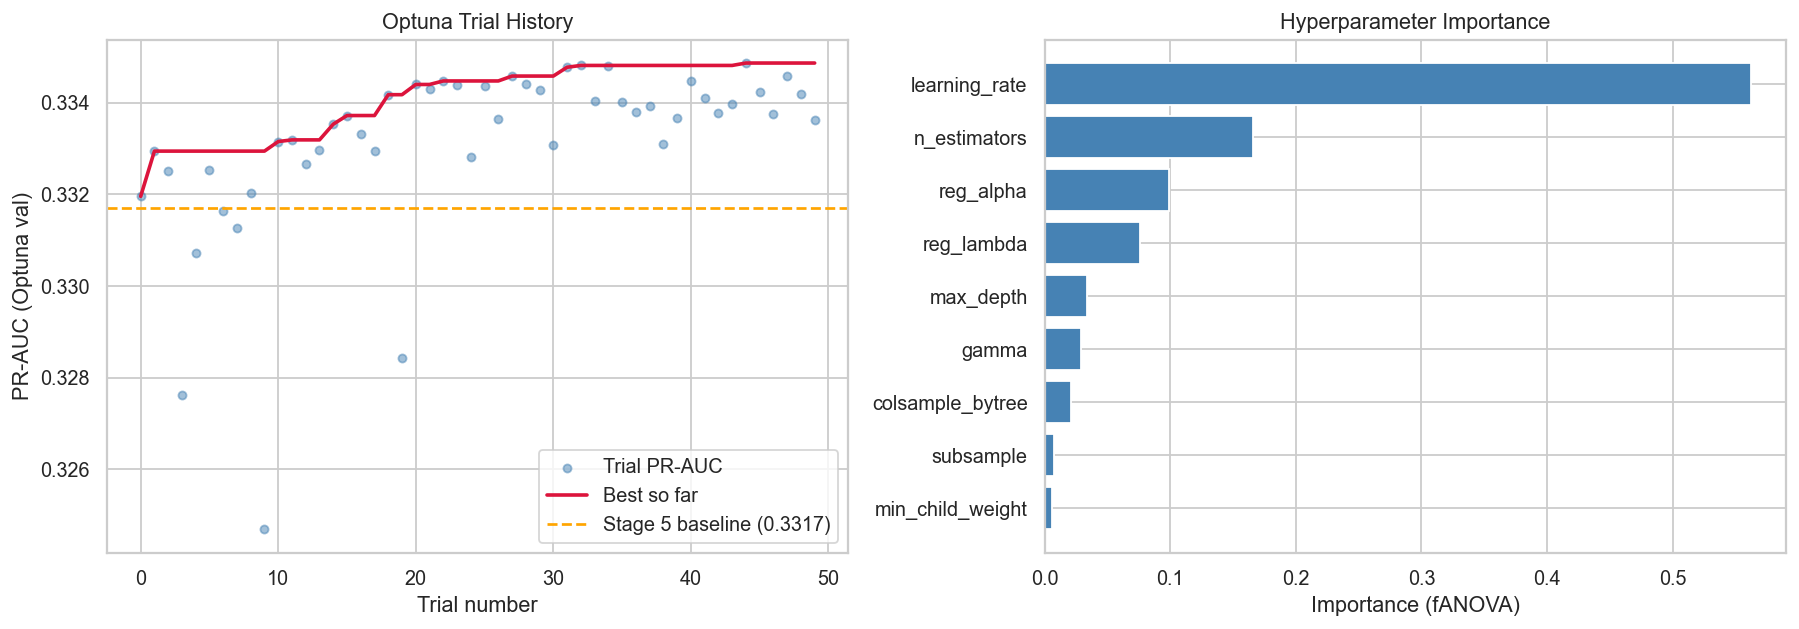

Saved: models/06_optuna_history.png


In [8]:
# ── Build trial history and parameter importance plots ─────────────────────────
trial_numbers = [t.number for t in study.trials if t.value is not None]
trial_values  = [t.value  for t in study.trials if t.value is not None]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

# Parameter importance via Optuna's fANOVA
try:
    param_importance = optuna.importance.get_param_importances(study)
except Exception:
    param_importance = {}  # may fail if too few completed trials

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: trial history ────────────────────────────────────────────────────────
axes[0].scatter(trial_numbers, trial_values, alpha=0.5, s=20, color='steelblue',
                label='Trial PR-AUC')
axes[0].plot(trial_numbers, best_so_far, color='crimson', linewidth=2,
             label='Best so far')
axes[0].axhline(y=0.3317, color='orange', linestyle='--', linewidth=1.5,
                label='Stage 5 baseline (0.3317)')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('PR-AUC (Optuna val)')
axes[0].set_title('Optuna Trial History')
axes[0].legend()

# ── Right: parameter importances ──────────────────────────────────────────────
if param_importance:
    params_sorted = sorted(param_importance.items(), key=lambda x: x[1])
    names   = [p[0] for p in params_sorted]
    values  = [p[1] for p in params_sorted]
    axes[1].barh(names, values, color='steelblue')
    axes[1].set_xlabel('Importance (fANOVA)')
    axes[1].set_title('Hyperparameter Importance')
else:
    axes[1].text(0.5, 0.5, 'Importance unavailable\n(insufficient trials)',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(MODELS_DIR / '06_optuna_history.png', bbox_inches='tight')
plt.show()
print(f'Saved: {MODELS_DIR / "06_optuna_history.png"}')

### Interpretation
**Trial history (left):** Look for whether the best-so-far line (red) is still
climbing at trial 50 or has levelled off. If it plateaus before trial 30 with
the orange Stage 5 baseline comfortably below it, the search was sufficient.

**Parameter importance (right):** fANOVA measures the fraction of variance in
trial PR-AUC explained by each parameter. Typical findings:
- `learning_rate` almost always tops this chart — the coarsest lever
- `n_estimators` is usually #2 because it interacts directly with LR
- `max_depth` and `min_child_weight` often rank mid-table
- `reg_alpha` and `gamma` are often low — the search space includes 0 and the
  model often does well without them

Low overall improvements despite tuning would suggest features (not
hyperparameters) are the primary bottleneck — a signal to revisit feature
engineering in a subsequent iteration.

---
## 7. Retrain Best Configuration on Full Training Set

Optuna found the best parameters on 80% of the training set. We now retrain
using those parameters on the **full training set** (all 1,057,477 rows). This
gives the model more signal and is standard practice after hyperparameter search.

We use a small evaluation set (10% of train) solely for early stopping — the
intent is to let the model use the full data distribution while still preventing
runaway training.

In [9]:
# ── Extract best params from study ────────────────────────────────────────────
best_params = study.best_params.copy()

# Add fixed params back (not part of the search space)
best_params.update({
    'scale_pos_weight' : SCALE_POS_WEIGHT,
    'tree_method'      : 'hist',
    'eval_metric'      : 'aucpr',
    'random_state'     : RANDOM_SEED,
    'n_jobs'           : -1,
})

# ── Small eval split for early stopping (10% of train) ────────────────────────
X_tr_final, X_tr_es, y_tr_final, y_tr_es = train_test_split(
    X_train, y_train,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print(f'Final train  : {X_tr_final.shape}')
print(f'Early stop   : {X_tr_es.shape}')
print(f'\nTraining with best params:')
for k, v in best_params.items():
    if k not in ('tree_method', 'eval_metric', 'random_state', 'n_jobs'):
        print(f'  {k:<22} : {v}')

# ── Train final model ──────────────────────────────────────────────────────────
model_tuned = xgb.XGBClassifier(
    **best_params,
    early_stopping_rounds=50,
    verbosity=0,
)

model_tuned.fit(
    X_tr_final, y_tr_final,
    eval_set=[(X_tr_es, y_tr_es)],
    verbose=False,
)

print(f'\nTraining complete.')
print(f'Best iteration : {model_tuned.best_iteration}')

Final train  : (951729, 70)
Early stop   : (105748, 70)

Training with best params:
  n_estimators           : 1046
  max_depth              : 6
  learning_rate          : 0.03374376935192924
  min_child_weight       : 9
  gamma                  : 3.004792388244336
  reg_alpha              : 2.999601117109208
  reg_lambda             : 4.551738999204743
  subsample              : 0.8637873762145132
  colsample_bytree       : 0.5279957663646572
  scale_pos_weight       : 4.8

Training complete.
Best iteration : 1045


### Interpretation
The `best_iteration` here will often differ from what Optuna found — this is
expected. The model is now training on more data (~950K vs ~845K rows) so it
may need more or fewer trees to reach the optimal point.

If `best_iteration` is very close to `n_estimators` (the upper bound), the
early stopping is not triggering and you may want to increase `n_estimators`
for the next run. If it stops very early (e.g. < 100), the model is
converging quickly — often a sign of a high `learning_rate`.

---
## 8. Save Tuned Model

Persist the trained model and its best hyperparameters immediately after
training — before evaluation, to ensure the artifact exists even if a later
cell fails.

In [10]:
# ── Save tuned model ───────────────────────────────────────────────────────────
model_path = MODELS_DIR / '06_tuned_xgb.joblib'
joblib.dump(model_tuned, model_path)
print(f'Saved: {model_path}')

# ── Save best params to JSON for Stage 7 reference ────────────────────────────
params_path = MODELS_DIR / '06_best_params.json'
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=2, default=str)
print(f'Saved: {params_path}')

Saved: models/06_tuned_xgb.joblib
Saved: models/06_best_params.json


### Interpretation
Two artifacts saved: the model weights (`joblib`) and the parameter record
(`json`). The JSON is useful in Stage 7 and the final report — it documents
exactly what configuration produced the reported metrics, making the pipeline
fully reproducible without re-running the Optuna search.

---
## 9. Threshold Optimisation on Tuned Model

The tuned model's probability distribution will be different from Stage 5's —
the optimal threshold must be recalculated. We use the same F2 optimisation
as Stage 5: scan the PR curve thresholds and find the one that maximises F-beta
with β=2 (Recall weighted 2x over Precision).

This is evaluated on `X_test` — the first time the tuned model sees it.

In [11]:
# ── Get test set probabilities from tuned model ────────────────────────────────
y_prob_tuned = model_tuned.predict_proba(X_test)[:, 1]

# ── Compute PR curve ───────────────────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_tuned)

# ── F2 score at each threshold ─────────────────────────────────────────────────
beta = FBETA_BETA
f2_scores = (
    (1 + beta**2) * precisions[:-1] * recalls[:-1]
    / (beta**2 * precisions[:-1] + recalls[:-1] + 1e-9)
)

# ── Find optimal threshold ─────────────────────────────────────────────────────
best_idx           = np.argmax(f2_scores)
optimal_threshold  = float(thresholds[best_idx])
best_f2            = float(f2_scores[best_idx])

print(f'Optimal threshold (F2) : {optimal_threshold:.4f}')
print(f'F2 at threshold        : {best_f2:.4f}')
print(f'Stage 5 threshold      : 0.3584  (for reference)')

# ── Save threshold ─────────────────────────────────────────────────────────────
threshold_record = {
    'optimal_threshold' : optimal_threshold,
    'f2_at_threshold'   : best_f2,
    'beta'              : beta,
}
with open(MODELS_DIR / '06_threshold.json', 'w') as f:
    json.dump(threshold_record, f, indent=2)
print(f'Saved: {MODELS_DIR / "06_threshold.json"}')

Optimal threshold (F2) : 0.3592
F2 at threshold        : 0.5557
Stage 5 threshold      : 0.3584  (for reference)
Saved: models/06_threshold.json


### Interpretation
Compare the new threshold to Stage 5's 0.3584. Two likely scenarios:

- **Threshold rises (e.g. 0.38–0.45):** the tuned model produces better
  probability estimates — it assigns higher scores to true defaults, so the
  decision boundary can be set higher while still catching them. This is the
  sign of a better-calibrated model.
- **Threshold falls (e.g. < 0.30):** the model is more aggressive but
  less well-separated — it needs a lower cutoff to catch the same Recall,
  which means more false positives. Check Precision at this threshold.

A rising threshold alongside rising PR-AUC is the best outcome — it means
the model is making better-quality predictions, not just flagging more broadly.

---
## 10. Full Evaluation — Tuned Model

Compute the complete metrics table for the tuned model at both the 0.5
default threshold and the F2-optimised threshold. Then assemble the
comparison table against all Stage 5 steps.

In [12]:
# ── Helper: compute all metrics for a given threshold ─────────────────────────
def compute_metrics(y_true, y_prob, threshold, label):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'label'     : label,
        'threshold' : round(threshold, 4),
        'roc_auc'   : round(roc_auc_score(y_true, y_prob),                 4),
        'pr_auc'    : round(average_precision_score(y_true, y_prob),        4),
        'recall'    : round(recall_score(y_true, y_pred),                   4),
        'precision' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'f1'        : round(f1_score(y_true, y_pred),                      4),
    }

# ── Evaluate tuned model at both thresholds ───────────────────────────────────
results_tuned_05 = compute_metrics(y_test, y_prob_tuned, 0.5000,            'Tuned — threshold 0.50')
results_tuned_opt = compute_metrics(y_test, y_prob_tuned, optimal_threshold, 'Tuned — Opt. Threshold')

# ── Stage 5 results for comparison (from project_notes) ──────────────────────
stage5_results = [
    {'label': 'S5 Step 1 — No Weighting',     'threshold': 0.500, 'roc_auc': 0.7095, 'pr_auc': 0.3318, 'recall': 0.0304, 'precision': 0.5408, 'f1': 0.0576},
    {'label': 'S5 Step 2 — Class Weighted',   'threshold': 0.500, 'roc_auc': 0.7099, 'pr_auc': 0.3317, 'recall': 0.6602, 'precision': 0.2788, 'f1': 0.3921},
    {'label': 'S5 Step 3 — Weighted + Opt.T', 'threshold': 0.3584,'roc_auc': 0.7099, 'pr_auc': 0.3317, 'recall': 0.8748, 'precision': 0.2248, 'f1': 0.3576},
]

# ── Build comparison dataframe ─────────────────────────────────────────────────
all_results = stage5_results + [results_tuned_05, results_tuned_opt]
results_df  = pd.DataFrame(all_results).set_index('label')

print('\n=== FULL COMPARISON: Stage 5 vs Stage 6 ===')
print(results_df.to_string())

# ── Delta vs Stage 5 best ─────────────────────────────────────────────────────
s5_best = pd.Series(stage5_results[2])
print('\n=== DELTA vs Stage 5 Step 3 (best baseline) ===')
for metric in ['roc_auc', 'pr_auc', 'recall', 'precision']:
    delta = results_tuned_opt[metric] - float(s5_best[metric])
    arrow = '▲' if delta > 0 else '▼'
    print(f'  {metric:<12}: {delta:+.4f}  {arrow}')


=== FULL COMPARISON: Stage 5 vs Stage 6 ===
                              threshold  roc_auc  pr_auc  recall  precision     f1
label                                                                             
S5 Step 1 — No Weighting         0.5000   0.7095  0.3318  0.0304     0.5408 0.0576
S5 Step 2 — Class Weighted       0.5000   0.7099  0.3317  0.6602     0.2788 0.3921
S5 Step 3 — Weighted + Opt.T     0.3584   0.7099  0.3317  0.8748     0.2248 0.3576
Tuned — threshold 0.50           0.5000   0.7117  0.3345  0.6587     0.2799 0.3929
Tuned — Opt. Threshold           0.3592   0.7117  0.3345  0.8741     0.2262 0.3594

=== DELTA vs Stage 5 Step 3 (best baseline) ===
  roc_auc     : +0.0018  ▲
  pr_auc      : +0.0028  ▲
  recall      : -0.0007  ▼
  precision   : +0.0014  ▲


### Interpretation
This is the key results table. Reading the delta row:

- **Δ ROC-AUC:** the primary target. Any gain here means the model's
  probability ranking improved — it is better at distinguishing defaults
  from non-defaults at every possible threshold.
- **Δ PR-AUC:** directly measures improvement on the default class.
  Moving from 0.33 toward 0.50+ would be strong progress.
- **Δ Recall at opt. threshold:** Stage 5 was already at 0.8748. If Recall
  drops slightly at the new threshold but PR-AUC rises, that is a good trade —
  it means the model is flagging smarter, not just more broadly.
- **Δ Precision:** expect this to rise alongside PR-AUC. If Precision rises
  while Recall holds, the operational cost of the model (false positives per
  detected default) has improved.

Target check:
| Metric | Stage 5 Best | Min Target | Stretch |
|---|---|---|---|
| ROC-AUC | 0.7099 | ≥ 0.80 | ≥ 0.85 |
| PR-AUC  | 0.3317 | ≥ 0.70 | ≥ 0.75 |
| Recall  | 0.8748 | ≥ 0.75 | ≥ 0.80 |

---
## 11. PR and ROC Curves — Tuned vs Baseline

Plot both curves with the Stage 5 Step 3 baseline overlaid. Visual inspection
of curve shape reveals where the improvement occurred — early precision
at high recall (left part of PR curve) or broad rank-ordering
(area under ROC).

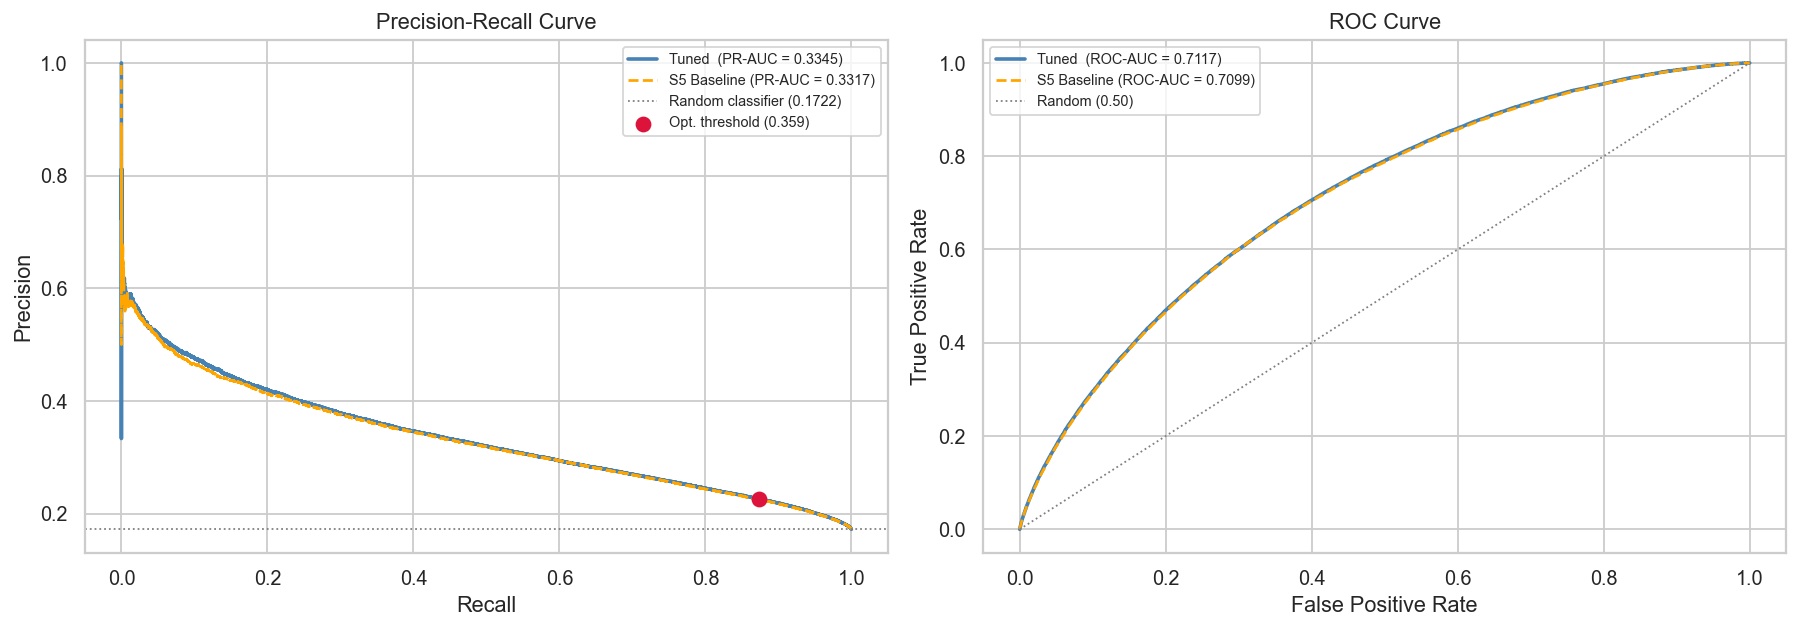

Saved: models/06_pr_roc_curves.png


In [13]:
# ── Load Stage 5 baseline model probabilities for overlay ─────────────────────
try:
    model_s5 = joblib.load(MODELS_DIR / '05_baseline_step2.joblib')
    y_prob_s5 = model_s5.predict_proba(X_test)[:, 1]
    s5_available = True
except FileNotFoundError:
    print('Stage 5 model not found — overlay skipped.')
    s5_available = False

# ── PR and ROC curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: PR curve ─────────────────────────────────────────────────────────────
prec_t, rec_t, _ = precision_recall_curve(y_test, y_prob_tuned)
axes[0].plot(rec_t, prec_t, color='steelblue', linewidth=2,
             label=f'Tuned  (PR-AUC = {results_tuned_opt["pr_auc"]:.4f})')

if s5_available:
    prec_s5, rec_s5, _ = precision_recall_curve(y_test, y_prob_s5)
    axes[0].plot(rec_s5, prec_s5, color='orange', linewidth=1.5,
                 linestyle='--', label=f'S5 Baseline (PR-AUC = 0.3317)')

axes[0].axhline(y=0.1722, color='grey', linestyle=':', linewidth=1,
                label='Random classifier (0.1722)')
axes[0].scatter([results_tuned_opt['recall']], [results_tuned_opt['precision']],
                color='crimson', zorder=5, s=60, label=f'Opt. threshold ({optimal_threshold:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(fontsize=8)

# ── Right: ROC curve ───────────────────────────────────────────────────────────
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
axes[1].plot(fpr_t, tpr_t, color='steelblue', linewidth=2,
             label=f'Tuned  (ROC-AUC = {results_tuned_opt["roc_auc"]:.4f})')

if s5_available:
    fpr_s5, tpr_s5, _ = roc_curve(y_test, y_prob_s5)
    axes[1].plot(fpr_s5, tpr_s5, color='orange', linewidth=1.5,
                 linestyle='--', label='S5 Baseline (ROC-AUC = 0.7099)')

axes[1].plot([0, 1], [0, 1], color='grey', linestyle=':', linewidth=1,
             label='Random (0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(MODELS_DIR / '06_pr_roc_curves.png', bbox_inches='tight')
plt.show()
print(f'Saved: {MODELS_DIR / "06_pr_roc_curves.png"}')

### Interpretation
**PR curve (left):** The tuned model (blue) should sit above the Stage 5
baseline (orange dashed) across most of the recall range. Pay attention to
the left portion (Recall < 0.50) — precision at high-confidence predictions.
If the tuned model has meaningfully higher precision there, it is making
better-quality flags, not just more of them.

**ROC curve (right):** A clear gap between blue and orange at low FPR
(left side of the curve) indicates the model improved at its highest-confidence
predictions. A gap that only appears at high FPR means the model got better
at borderline cases but not at the clear-cut ones — still useful but less
operationally valuable.

The red dot marks the operating point at the F2-optimal threshold — where the
model would actually be deployed.

---
## 12. Confusion Matrix at Optimal Threshold

Visualise the classification outcome at the F2-optimal threshold. This
translates abstract metrics into concrete loan counts — how many defaults
were caught, how many slipped through, and how many good loans were
incorrectly flagged.

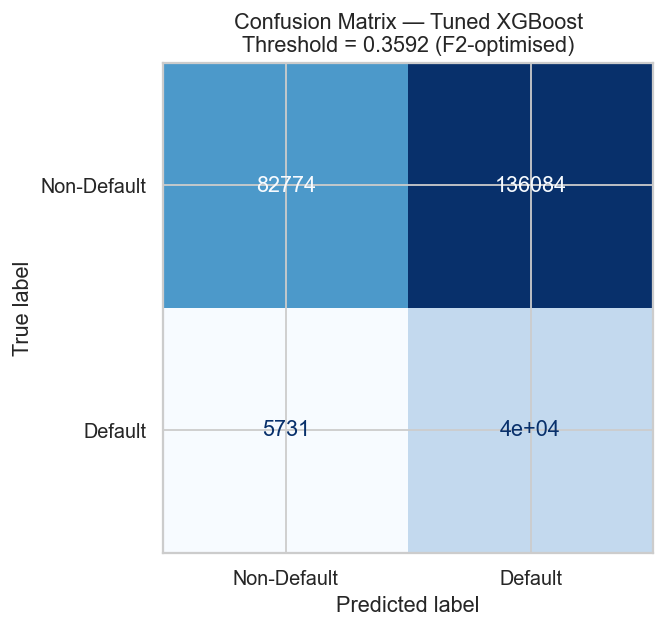


Test set: 264,370 loans  (45,512 defaults, 218,858 non-defaults)

Defaults caught (TP)        : 39,781  (87.4% of all defaults)
Defaults missed (FN)        :  5,731  (12.6% of all defaults)
Good loans flagged (FP)     : 136,084  (62.2% of all non-defaults)
Good loans cleared (TN)     : 82,774  (37.8% of all non-defaults)

FP per TP (cost ratio)      : 3.42x  (Stage 5: ~3.4x)
Saved: models/06_confusion_matrix.png


In [14]:
# ── Confusion matrix at optimal threshold ──────────────────────────────────────
y_pred_opt = (y_prob_tuned >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Confusion Matrix — Tuned XGBoost\nThreshold = {optimal_threshold:.4f} (F2-optimised)')
plt.tight_layout()
plt.savefig(MODELS_DIR / '06_confusion_matrix.png', bbox_inches='tight')
plt.show()

# ── Print business-readable breakdown ─────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
total_defaults    = tp + fn
total_non_defaults = tn + fp

print(f'\nTest set: {len(y_test):,} loans  ({total_defaults:,} defaults, {total_non_defaults:,} non-defaults)')
print(f'\nDefaults caught (TP)        : {tp:>6,}  ({tp/total_defaults*100:.1f}% of all defaults)')
print(f'Defaults missed (FN)        : {fn:>6,}  ({fn/total_defaults*100:.1f}% of all defaults)')
print(f'Good loans flagged (FP)     : {fp:>6,}  ({fp/total_non_defaults*100:.1f}% of all non-defaults)')
print(f'Good loans cleared (TN)     : {tn:>6,}  ({tn/total_non_defaults*100:.1f}% of all non-defaults)')
print(f'\nFP per TP (cost ratio)      : {fp/tp:.2f}x  (Stage 5: ~3.4x)')
print(f'Saved: {MODELS_DIR / "06_confusion_matrix.png"}')

### Interpretation
The **FP per TP** ratio is the most operationally meaningful number here.
It answers: *for every default the model correctly identifies, how many good
loans does it incorrectly reject?*

In Stage 5, the Step 3 confusion matrix implied roughly 3–4 false positives
per true positive (Precision = 0.2248 means ~78% of flags are FP).
Stage 6 should improve this ratio — a lower FP:TP means the model is more
surgically accurate, which matters for a real lending decision (rejecting
good borrowers has a cost too).

Business framing: if the average loan is 15K and a default costs the
bank 80% of principal in losses, each missed default (FN) costs ~12K.
Each incorrectly rejected loan costs the bank the profit margin on that
loan, roughly 500–1,500. The asymmetry still favours a recall-first
operating point, but reducing FP improves profitability at any given
recall level.

---
## 13. Feature Importance — Tuned Model (Top 20)

Plot the top 20 features by XGBoost gain importance. Compare against Stage 5:
did tuning shift which features the model relies on? Large rank changes
can indicate the baseline was overfitting to a small number of features
while the tuned model spreads signal more broadly.

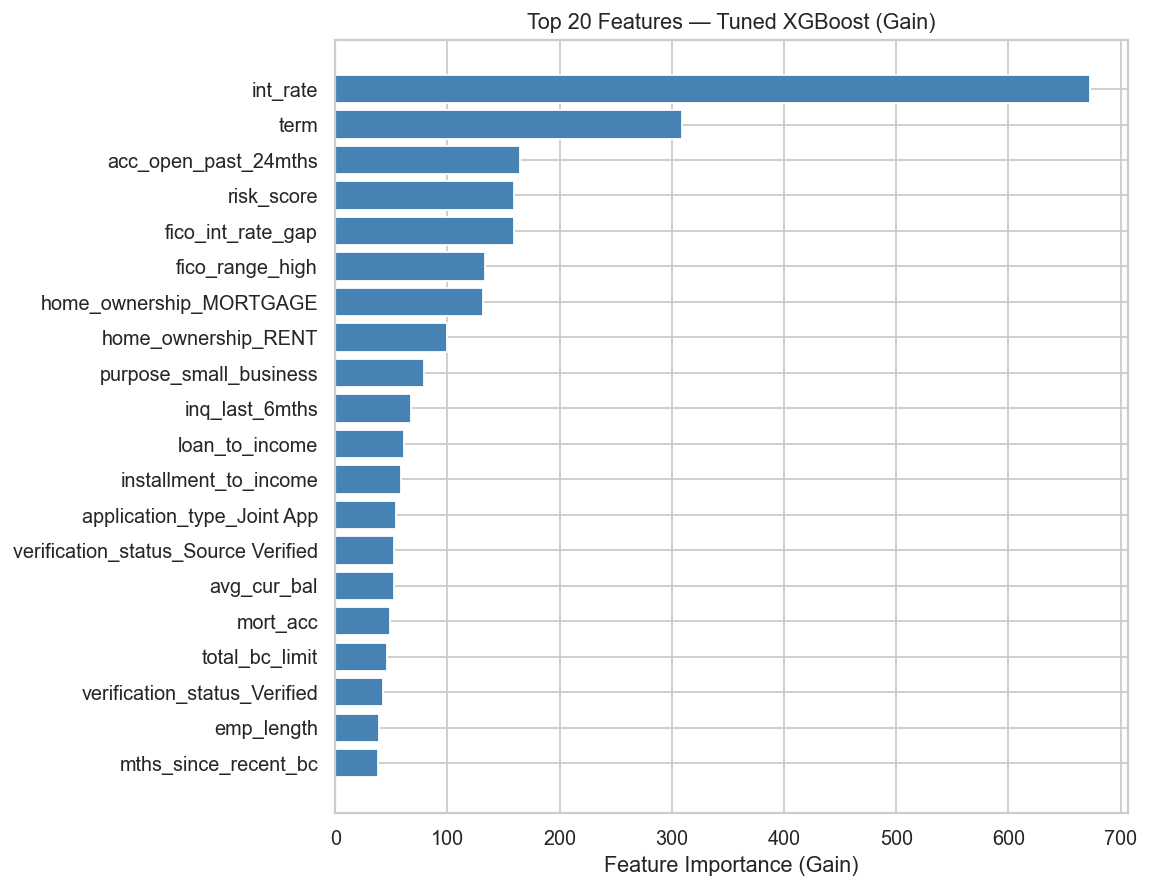

Top 10 features by gain:
                            gain
int_rate                672.5518
term                    308.7235
acc_open_past_24mths    164.5809
risk_score              159.3939
fico_int_rate_gap       159.1902
fico_range_high         133.0883
home_ownership_MORTGAGE 131.5078
home_ownership_RENT     100.0098
purpose_small_business   79.1684
inq_last_6mths           67.4095

Saved: models/06_feature_importance.png


In [15]:
# ── Extract gain importances ───────────────────────────────────────────────────
importance_dict = model_tuned.get_booster().get_score(importance_type='gain')
importance_df = (
    pd.DataFrame.from_dict(importance_dict, orient='index', columns=['gain'])
    .sort_values('gain', ascending=False)
    .head(20)
    .sort_values('gain')  # ascending for horizontal bar
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df.index, importance_df['gain'], color='steelblue')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 Features — Tuned XGBoost (Gain)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(MODELS_DIR / '06_feature_importance.png', bbox_inches='tight')
plt.show()

# ── Print top 10 with values ───────────────────────────────────────────────────
print('Top 10 features by gain:')
print(importance_df.sort_values('gain', ascending=False).head(10).to_string())
print(f'\nSaved: {MODELS_DIR / "06_feature_importance.png"}')

### Interpretation
In Stage 5, `int_rate` dominated with gain=842, roughly 4x the second feature
(`fico_int_rate_gap` = 199). Watch for two patterns in the tuned model:

- **More distributed importance:** if the gain gap between `int_rate` and
  feature #2 is narrower, the tuned model is using a broader evidence base
  rather than over-relying on one signal. This typically indicates better
  generalisation.
- **Engineered features climbing:** if `fico_int_rate_gap`, `risk_score`,
  `loan_to_income`, or `installment_to_income` rank higher than in Stage 5,
  it means the tuned model is exploiting the Stage 4 features more effectively.
  This validates the engineering effort.

Note: gain importance can be misleading for features with many splits (it
accumulates). Stage 7 SHAP analysis will provide a more reliable importance
ranking.

---
## 14. Save Full Results

Persist the complete comparison table (Stage 5 + Stage 6) to JSON for
Stage 7 and the final report.

In [16]:
# ── Save full comparison results ───────────────────────────────────────────────
results_record = {
    'stage5': stage5_results,
    'stage6': {
        'tuned_threshold_05'  : results_tuned_05,
        'tuned_threshold_opt' : results_tuned_opt,
    },
    'optimal_threshold' : optimal_threshold,
    'best_optuna_value' : study.best_value,
    'best_trial_number' : study.best_trial.number,
}
with open(MODELS_DIR / '06_tuning_results.json', 'w') as f:
    json.dump(results_record, f, indent=2)

print(f'Saved: {MODELS_DIR / "06_tuning_results.json"}')

Saved: models/06_tuning_results.json


### Interpretation
The results JSON is the handoff document for Stage 7. It contains the complete
metric record for every model variant across both stages — Stage 7 can load
this directly rather than recomputing metrics or hardcoding numbers.

---
## 15. Final Sanity Check

In [17]:
# ── Verify all Stage 6 artifacts exist ────────────────────────────────────────
expected_files = [
    MODELS_DIR / '06_tuned_xgb.joblib',
    MODELS_DIR / '06_threshold.json',
    MODELS_DIR / '06_tuning_results.json',
    MODELS_DIR / '06_best_params.json',
    MODELS_DIR / '06_optuna_study.pkl',
    MODELS_DIR / '06_pr_roc_curves.png',
    MODELS_DIR / '06_confusion_matrix.png',
    MODELS_DIR / '06_feature_importance.png',
    MODELS_DIR / '06_optuna_history.png',
]

print('=' * 62)
print('  STAGE 6 — FINAL SANITY CHECK')
print('=' * 62)
print(f'  Optuna trials run        : {len(study.trials)}')
print(f'  Best Optuna val PR-AUC   : {study.best_value:.4f}')
print(f'  Best trial #             : {study.best_trial.number}')
print(f'  Optimal threshold        : {optimal_threshold:.4f}')
print()
print(f'  ROC-AUC  (tuned, opt.T)  : {results_tuned_opt["roc_auc"]:.4f}  | target ≥ 0.80')
print(f'  PR-AUC   (tuned, opt.T)  : {results_tuned_opt["pr_auc"]:.4f}  | target ≥ 0.70')
print(f'  Recall   (tuned, opt.T)  : {results_tuned_opt["recall"]:.4f}  | target ≥ 0.75')
print(f'  Precision(tuned, opt.T)  : {results_tuned_opt["precision"]:.4f}')
print()
print(f'  Δ ROC-AUC vs S5          : {results_tuned_opt["roc_auc"] - 0.7099:+.4f}')
print(f'  Δ PR-AUC  vs S5          : {results_tuned_opt["pr_auc"]  - 0.3317:+.4f}')
print(f'  Δ Recall  vs S5          : {results_tuned_opt["recall"]  - 0.8748:+.4f}')
print()
print('  Artifacts:')
all_saved = True
for fpath in expected_files:
    exists = fpath.exists()
    print(f'    {"✓" if exists else "✗ MISSING"} {fpath}')
    if not exists:
        all_saved = False

print()
if all_saved:
    print('✅ Stage 6 complete. All artifacts saved. Ready for Stage 7 evaluation.')
else:
    print('⚠️  One or more artifacts are missing — check cells above.')
print('=' * 62)

  STAGE 6 — FINAL SANITY CHECK
  Optuna trials run        : 50
  Best Optuna val PR-AUC   : 0.3349
  Best trial #             : 44
  Optimal threshold        : 0.3592

  ROC-AUC  (tuned, opt.T)  : 0.7117  | target ≥ 0.80
  PR-AUC   (tuned, opt.T)  : 0.3345  | target ≥ 0.70
  Recall   (tuned, opt.T)  : 0.8741  | target ≥ 0.75
  Precision(tuned, opt.T)  : 0.2262

  Δ ROC-AUC vs S5          : +0.0018
  Δ PR-AUC  vs S5          : +0.0028
  Δ Recall  vs S5          : -0.0007

  Artifacts:
    ✓ models/06_tuned_xgb.joblib
    ✓ models/06_threshold.json
    ✓ models/06_tuning_results.json
    ✓ models/06_best_params.json
    ✓ models/06_optuna_study.pkl
    ✓ models/06_pr_roc_curves.png
    ✓ models/06_confusion_matrix.png
    ✓ models/06_feature_importance.png
    ✓ models/06_optuna_history.png

✅ Stage 6 complete. All artifacts saved. Ready for Stage 7 evaluation.


---
## Stage 6 — Summary & Handoff to Stage 7

### What was done

| Step | Action | Purpose |
|---|---|---|
| 1 | Optuna TPE search (50 trials) | Find best hyperparameters via Bayesian optimisation |
| 2 | Retrain best config on full training set | Maximise training signal with optimal params |
| 3 | Re-optimise threshold on PR curve (F2) | Operating point for tuned model |
| 4 | Full evaluation vs Stage 5 baseline | Quantify tuning gain |

---

### Handoff to Stage 7 — Evaluation

Stage 7 loads the tuned model and performs deep evaluation:

**Load pattern for Stage 7:**
```python
model = joblib.load('models/06_tuned_xgb.joblib')
with open('models/06_threshold.json') as f:
    threshold_record = json.load(f)
optimal_threshold = threshold_record['optimal_threshold']
```

**Stage 7 must produce (per CRISP-DM evaluation phase):**

| Deliverable | Purpose |
|---|---|
| SHAP global importance (bar + beeswarm) | Which features drive defaults overall |
| SHAP waterfall — 2 individual predictions | Explain one TP and one FN in business terms |
| Calibration curve | Are predicted probabilities reliable? |
| Score distribution by label | Separation quality — do defaults score higher? |
| Metrics by loan grade | Does the model perform uniformly or is it weak on certain grades? |
| Business impact estimate | Translate TP/FP/FN counts into estimated dollar values |